In [ ]:
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import pandas as pd
from data_manager import load_session

In [ ]:
def plot_subject_hours(df):
    subject_hours = df.groupby('Subject')["Hours"].sum()

    plt.bar(subject_hours.index, subject_hours.values)
    plt.xlabel("Subject")
    plt.ylabel("Total Study Hours")
    plt.title("Study Hours per Subject")
    
    plt.show()


In [ ]:
def productivity_vs_hours(df):
    plt.scatter(df["Hours"],df["Productivity"])
    plt.xlabel("Hours")
    plt.ylabel("Productivity")
    plt.title("Productivity v/s Hours")

    plt.show()

In [ ]:
df = load_session()
df["Date"] = df["Date"].str.strip()
df["Date"] = pd.to_datetime(df["Date"],dayfirst=True, format = "%d-%m-%Y")

months = df["Date"].dt.month_name().unique()

df["Month"] = df["Date"].dt.month_name()

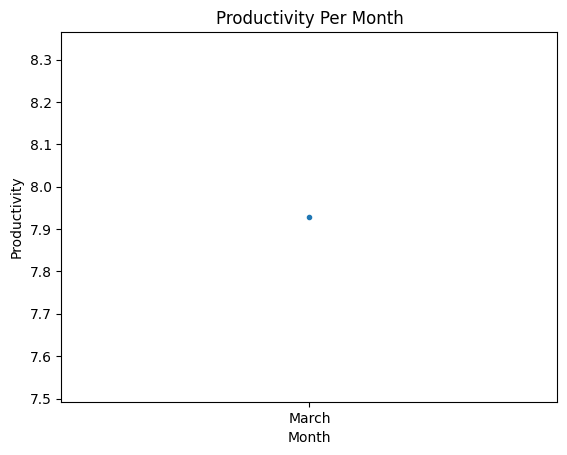

In [55]:
def productivity_per_month(df):

    df["MonthNum"] = df["Date"].dt.month
    df["Month"] = df["Date"].dt.month_name()
    data = df.groupby("MonthNum")["Productivity"].mean()

    months = data.index
    month_labels = [pd.to_datetime(str (m), format = "%m").strftime("%B") for m in months]
    
    plt.plot(month_labels, data.values, marker =".")
    
    plt.title("Productivity Per Month")
    plt.xlabel("Month")
    plt.ylabel("Productivity")

    plt.show()
productivity_per_month(df)

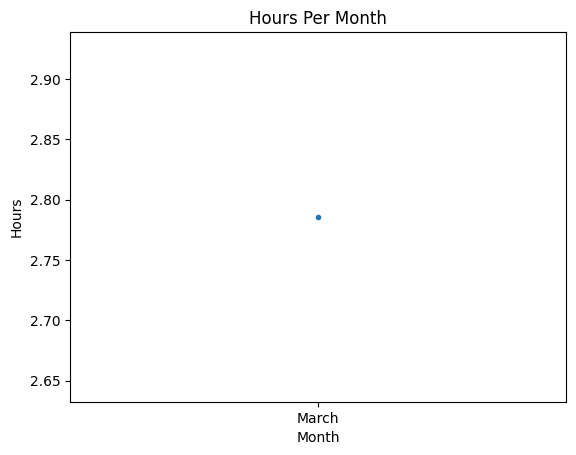

In [56]:
def hours_per_month(df):
    df["MonthNum"] = df["Date"].dt.month
    df["Month"] = df["Date"].dt.month_name()

    data = df.groupby("MonthNum")["Hours"].mean()

    months = data.index
    month_labels = [pd.to_datetime(str (m), format = "%m").strftime("%B") for m in months]
    plt.plot(month_labels,data.values, marker = ".")
    plt.title("Hours Per Month")
    plt.xlabel("Month")
    plt.ylabel("Hours")
    

    plt.show()

hours_per_month(df)

In [ ]:
def hours_per_day(df,month):

    month_df = df[df["Date"].dt.month_name()==month]
    month_df["Day"] = month_df["Date"].dt.day
    
    data = month_df.groupby("Day")["Hours"].sum()
    
    plt.plot(data.index, data.values, marker = ".")

    plt.title(f"Hours Per Day for {month}")
    plt.xlabel(f"Days of {month}")
    plt.ylabel("Hours")

    plt.show()

hours_per_day(df,"March")

In [ ]:
def productivity_per_day(df,month):
    month_df = df[df["Date"].dt.month_name()==month]
    month_df["Day"] = month_df["Date"].dt.day
    
    data = month_df.groupby("Day")["Productivity"].sum()
    
    plt.plot(data.index, data.values, marker = ".")

    plt.title(f"Hours Per Day for {month}")
    plt.xlabel(f"Days of {month}")
    plt.ylabel("Hours")

    plt.show()


In [ ]:
def analystic_dashboard(df):

    fig, ax = plt.subplots(2,2,figsize = (12,8))

    subject_data = df.groupby("Subject")["Hours"].sum()
    ax[0,0].bar(subject_data.index, subject_data.values)
    ax[0,0].set_title("Subjects vs Hours")

    ax[0,1].scatter(df["Hours"],df["Productivity"])
    ax[0,1].set_title("Hours vs Productivity")

    hours_month = df.groupby("Month")["Hours"].sum()
    ax[1,0].bar(hours_month.index,hours_month.values)
    ax[1,0].set_title("Hours vs Month")

    prod_month = df.groupby("Month")["Productivity"].mean()
    ax[1,1].plot(prod_month.index, prod_month.values, marker =".")
    ax[1,1].set_title("Month and Productivity")


    plt.tight_layout()
    plt.show()

analystic_dashboard(df)
